# Menota-_Stjórn_ Topic Analysis

This notebook will generate a complete term list for Menota and _Stjórn_, but right now I'm still just paring down the code duplicated from the stylometry notebook.

In [1]:
import os,glob,json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim import corpora
from gensim.models import LdaModel,LsiModel
import pyLDAvis.gensim_models
from sklearn.manifold import TSNE
from pprint import pprint

def set_xmargin(ax, left=0.0, right=0.3):
    ax.set_xmargin(0)
    ax.autoscale_view()
    lim = ax.get_xlim()
    delta = np.diff(lim)
    left = lim[0] - delta*left
    right = lim[1] + delta*right
    ax.set_xlim(left,right)

def normalize(target):
    # This dict limits orthographical variation beyond the rule sets
    # of stjorn-extract.ipynb and menota-extract.ipynb:
    matrix = {
        'j': 'i',
        'v': 'u',
        '': 'u', # &vacute;
        # Experiment with *either* normalizing ð to þ,
        # or else both to d (because AM 226 often uses d for ð):
        'ð': 'þ',
        #'ð': 'd',
        #'þ': 'd',
        'á': 'a',
        'ǽ': 'æ',
        'ę': 'æ',
        'é': 'e',
        'í': 'i',
        'ó': 'o',
        '': 'ǫ', # &oogonacute;
        'ú': 'u',
        'ý': 'y',
        'ǿ': 'ø',
        'k': 'c', # rather than vice versa, because of Latin (e.g. Lucifer)
        '[': '',
        ']': '',
        '%': '',
        '(': '',
        ')': '',
        '+': '',
        '/': '',
        '*aenl;': 'a',
        ':': '',
        ';': '',
        '<': '',
        '>': '',
        '?': '',
        '`': '',
        '´': '',
        '"': ''
        }
    for k,v in matrix.items():
        target = target.replace(k, v)
    return target


In [2]:
chunk_size = 2000

In [3]:
with open('token_indices.json') as index_file:
    token_indices = json.load(index_file)

titles = ['prologue', 'introduction', 'gn', 'ex', 'lv', 'nm', 'dt', 'ios', 'idc', 'rt', '1sm', '2sm', '3rg', '4rg']
work_indices = {
    'stjorn1': 650,
    'stjorn2': 124417,
    'stjorn3a': 147678,
    'stjorn4': 156943,
    'stjorn3b': 160719
}

tokens = []
for title in titles:
    with open(f"nlp/{title}.txt") as raw:
        document = normalize(raw.read().replace('\n', ' '))
        tokens.extend(document.split())

len(tokens)

271197

In [4]:
corpus = dict()
corpus['stj1'] = tokens[work_indices['stjorn1']:work_indices['stjorn2']]
corpus['stj2'] = tokens[work_indices['stjorn2']:work_indices['stjorn3a']]
corpus['stj3'] = tokens[work_indices['stjorn3a']:work_indices['stjorn4']] + tokens[work_indices['stjorn3b']:]
corpus['stj4'] = tokens[work_indices['stjorn4']:work_indices['stjorn3b']]

In [5]:
for text in glob.glob('../menota/dipl/*txt'):
    ref = os.path.basename(text).replace('.txt', '')
    with open(text) as doc:
        corpus[ref] = normalize(doc.read().replace('\n', '')).split()

In [6]:
terms = sorted(list(set([token for document in list(corpus.values()) for token in document if len(token) > 0])))

In [7]:
with open('all_terms.json', 'w', encoding='utf-8') as f:
    json.dump(terms, f, ensure_ascii=False, indent=4)

In [11]:
dictionary = corpora.Dictionary(corpus.values())
dictionary.filter_extremes(no_below=10, no_above=0.15)
dtmatrix = [dictionary.doc2bow(doc) for doc in corpus.values()]
#lsa = LsiModel(dtmatrix, num_topics=13, id2word=dictionary)
ldia = LdaModel(dtmatrix, num_topics=13, id2word=dictionary)

In [12]:
vis = pyLDAvis.gensim_models.prepare(ldia, dtmatrix, dictionary)
pyLDAvis.enable_notebook()
pyLDAvis.display(vis)

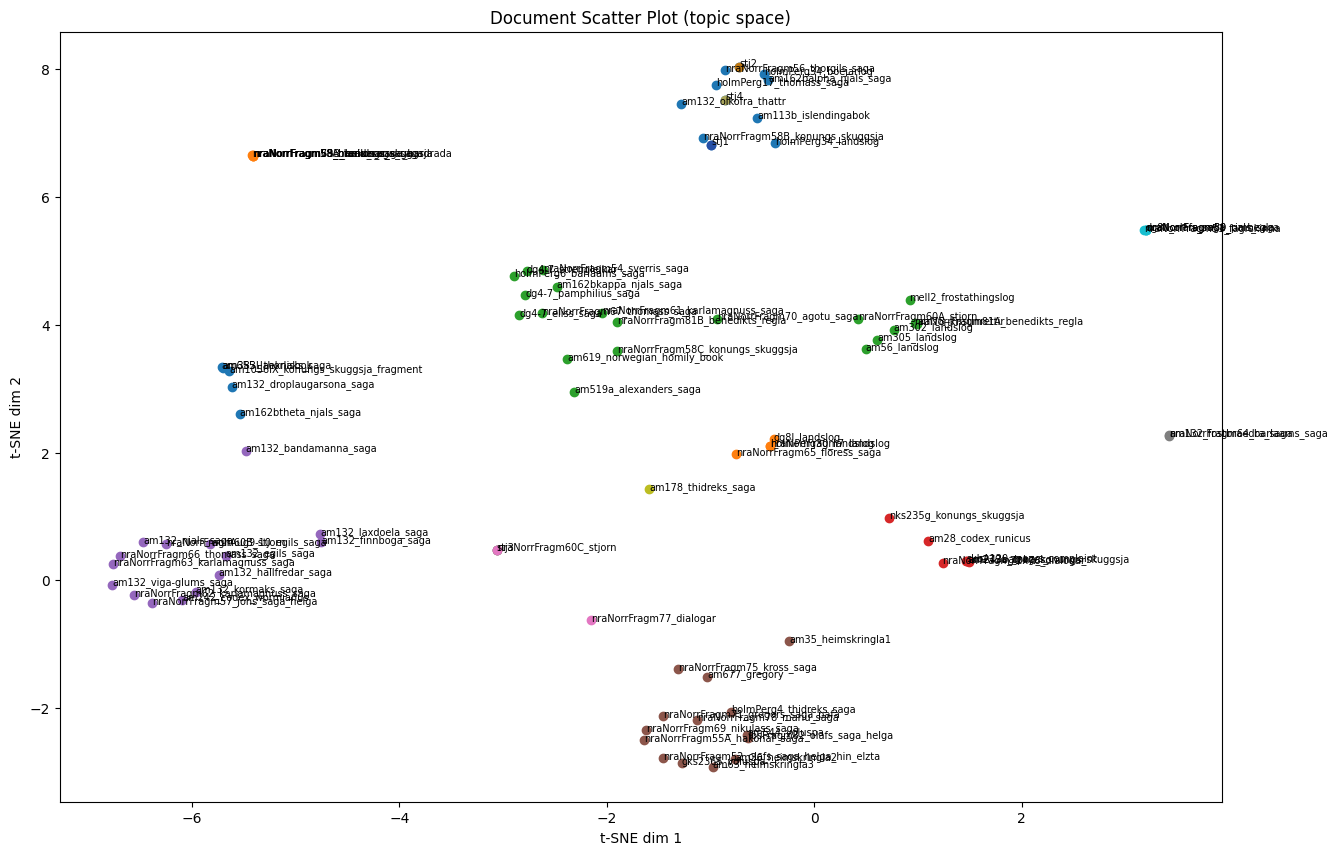

In [13]:
topic_dists = [ldia.get_document_topics(doc, minimum_probability=0) for doc in dtmatrix]
topic_matrix = np.array([[prob for _, prob in dist] for dist in topic_dists])
doc_coords = TSNE(n_components=2, random_state=42).fit_transform(topic_matrix)
doc_labels = list(corpus.keys())
plt.figure(figsize=(15,10))
color = ['#264FA6', '#C27A13', '#355E26', '#ABA75B']
ctr = 0
for i, label in enumerate(doc_labels):
    plt.scatter(doc_coords[i,0], doc_coords[i,1], c="C{}".format(np.argmax(topic_matrix[i])))
    plt.text(doc_coords[i,0], doc_coords[i,1], label, fontsize=7)
    if label.startswith('stj'):
        plt.scatter(doc_coords[i,0], doc_coords[i,1], c=color[ctr])
        ctr += 1
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.title("Document Scatter Plot (topic space)")
plt.show()